## Example 2c:
Example workflow that trains a CNN to predict the amplitude and phase aberration coefficients from a z-stack, using synthetic examples generated from the forwards model on-the-fly as training data.

The `ZstackSolver_Covariance` model fits the full covariance matrix over the coefficients, allowing each one to have not only its own uncertainty, but also to covary with other coefficients. From theory, we expect certain pairs of aberration coefficients to be correlated, which this model should be able to resolve.

In [1]:
import logging
import warnings

import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.training_utils import NoValidationBar
from cynosure.utilities.visualization import (
    plot_stack,
    plot_correlation_matrix,
    plot_coefficient_uncertainties,
)
from cynosure.zstack_decoding import (
    ZstackSolver_Covariance,
)

#### Simulation setup

In [4]:
train_cfg = get_default_training_config(generator_chunk=16)
sim_cfg = get_default_simulation_config(object_pixel_size=0.1)
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config(
    allowed_nm=(
        (0, 0),
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -1), (3, 1),
        (4, 0),
    )
)
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config(
    min_photons=10_000,
    max_photons=100_000,
)

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)

In [5]:
rng_seed = 123
dz = 0.2  # um, physical objective z-step
num_z = 7  # number of z-slices to fit, ~centered around the focal plane
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
z = torch.arange(-(num_z//2), num_z//2 + 1).float() * dz

#### Solver setup and training

In [7]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_Covariance(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    z_objective=z,
    object_distribution=object_distrib,
    noise_cfg=noise_cfg,
)
solver = solver.to(device)

Seed set to 123


In [8]:
trainer = pl.Trainer(
    max_epochs=15,
    accelerator=device,
    log_every_n_steps=50,
    callbacks=[NoValidationBar()],
)
trainer.fit(solver)
solver = solver.eval()

Sanity Checking: |                                                           | 0/? [00:00<?, ?it/s]

Training: |                                                                  | 0/? [00:00<?, ?it/s]

#### Sanity checking the results

You know the drill by now. Generate ground truth images and their aberration labels, re-predict the aberrations from the images, and check that the predicted aberrations produce similar images to the true ones.

In [9]:
batch_size = 4
with torch.inference_mode():
    images, phase_coefs, amp_coefs = solver.create_examples(batch_size)
    pred_phase_coefs, pred_amp_coefs = solver.predict_coefficients(images)
    pred_images = solver.simulate_normalized_stacks(pred_phase_coefs, pred_amp_coefs)

Arbitrarily choose the `batch_index=0` element to compare.

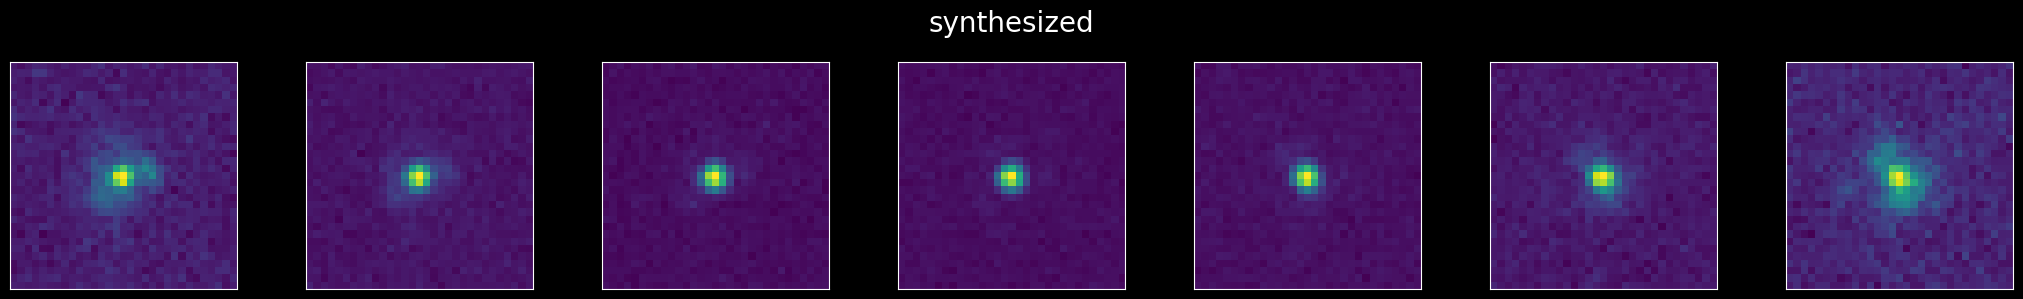

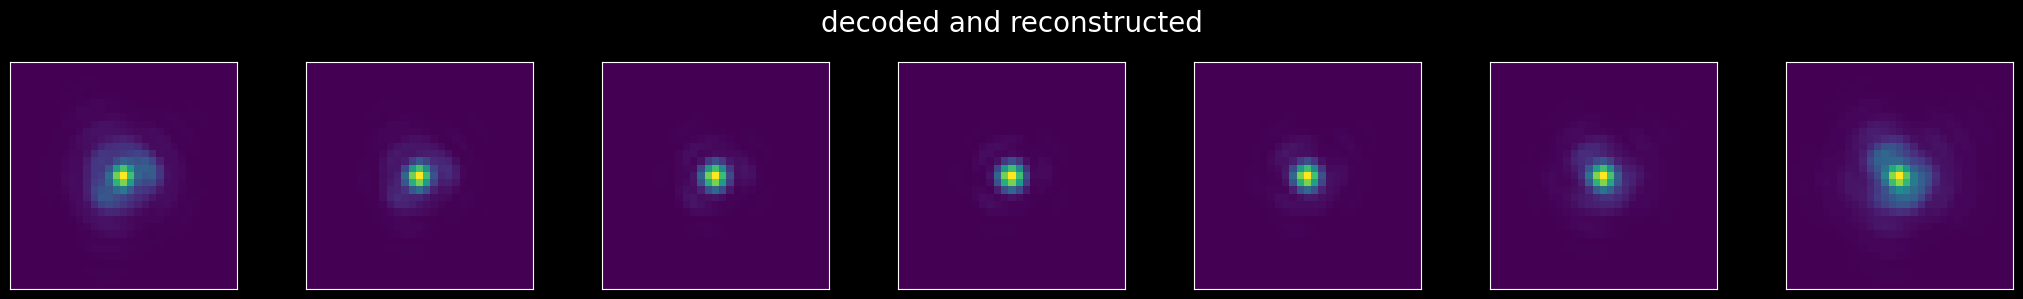

In [10]:
bidx = 0

fig1 = plot_stack(images.numpy(force=True)[bidx])
fig1.suptitle("synthesized", size=20)
fig1.tight_layout()

fig2 = plot_stack(pred_images.numpy(force=True)[bidx])
fig2.suptitle("decoded and reconstructed", size=20)
fig2.tight_layout()


#### Visualizing the predicted covariances

So far, this hasn't really been anything new. The advantage of this model is that we can create a bunch more examples, predict the distribution of coefficients for each, and plot the full covariance matrix of the predicted coefficients, averaged over the samples. Correlations between certain pairs of coefficients are expected, and their presence help validates the model.

In [11]:
with torch.inference_mode():
    images, phase_coefs, amp_coefs = solver.create_examples(256)
    dist = solver.predict_distribution(images)

In [12]:
kept_labels = solver.nonpiston_labels
num_kept_phase = solver.num_nonpiston_phase_coefs

covariances = dist.covariance_matrix
sigmas = covariances.diagonal(dim1=-2, dim2=-1).sqrt()
correlations = covariances / (sigmas.unsqueeze(-1) * sigmas.unsqueeze(-2))

Prominent positive correlations include those between $Z_{n}^{\pm 1}$ and $Z_{n+2}^{\pm 1}$, which makes sense, since overall translations of the beads will project onto superpositions of these terms.

The positive correlation between $Z_2^0$ and $Z_4^0$ is also expected, since defocus projects onto the set of $Z_{2n}^0$ coefficients. If we'd included the `n=6` coefficients in this fit, we'd expect to see that one correlated with this pair as well, provided we had enough resolving power.

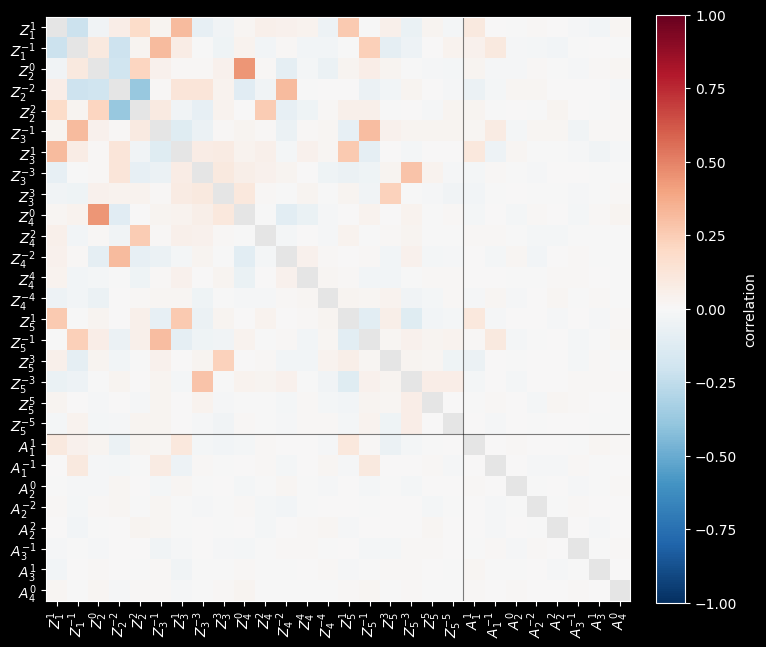

In [13]:
fig3 = plot_correlation_matrix(correlations.mean(0).numpy(force=True), kept_labels, num_phase=num_kept_phase)

Same plot as in `example_2b`, showing the model reducing the uncertainty of certain coefficients below that given by the prior:

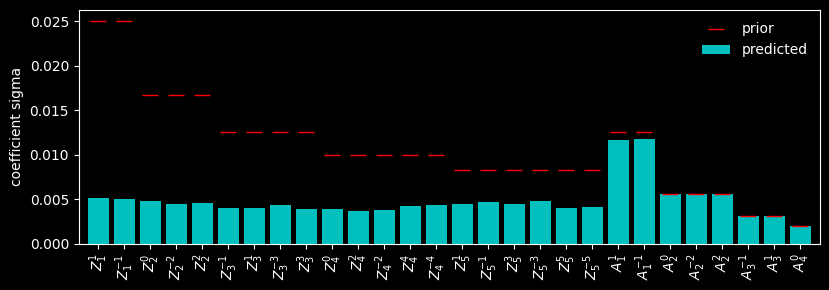

In [14]:
prior_sigmas = solver.gather_nonpiston(solver.target_scales)
fig4 = plot_coefficient_uncertainties(
    sigmas.mean(0).numpy(force=True),
    prior_sigmas.numpy(force=True),
    kept_labels,
)

As in `example_2b`, having `val/z_std` $\approx 1$ is evidence that the model's uncertainty is calibrated.

In [15]:
print(trainer.logged_metrics["val/z_std"])

tensor(0.9754)
